# Association Rule Mining: Discovering Hidden Relationships Among Clinicopathologic Variables

### Research Question

> Can association rule mining discover meaningful relationships among clinicopathologic characteristics of thyroid cancer patients, and which feature combinations occur most frequently together?

### Objectives

- Discover frequent itemsets from clinicopathologic variables.
- Generate association rules using Apriori and FP-Growth.
- Compare the discovered rules.
- Evaluate rules using Support, Confidence, Lift and Conviction.
- Identify the strongest clinical associations.

### - Import Libraries

In [91]:
# ==========================================================
# Path Setup
# ==========================================================

import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
sys.path.insert(0, str(PROJECT_ROOT / "Notebooks"))
DATA_DIR = PROJECT_ROOT / "Data"

# ==========================================================
# Data Handling
# ==========================================================

import pandas as pd
import numpy as np

# ==========================================================
# Visualization
# ==========================================================

import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import networkx as nx

# ==========================================================
# Association Rule Mining
# ==========================================================

from mlxtend.frequent_patterns import (
    apriori,
    fpgrowth,
    association_rules
)

# ==========================================================
# Utilities
# ==========================================================

import joblib

from utils import *

### - Load Dataset

In [2]:
# ==========================================================
# Load Transaction Dataset
# ==========================================================

transactions = pd.read_csv(DATA_DIR / "feature_association_transactions.csv")

transactions.head()

,bin__Gender_F,bin__Gender_M,bin__Smoking_No,bin__Smoking_Yes,bin__Hx Smoking_No,bin__Hx Smoking_Yes,bin__Hx Radiothreapy_No,bin__Hx Radiothreapy_Yes,bin__Focality_Multi-Focal,bin__Focality_Uni-Focal,...,nom__Stage_IVA,nom__Stage_IVB,nom__Response_Biochemical Incomplete,nom__Response_Excellent,nom__Response_Indeterminate,nom__Response_Structural Incomplete,nom__AgeGroup_Elder,nom__AgeGroup_Middle,nom__AgeGroup_Senior,nom__AgeGroup_Young
0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
4,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0


### 1) Inspect the dataset

In [3]:
transactions.shape

(380, 60)

In [4]:
transactions.info()

transactions.describe()

<class 'pandas.DataFrame'>
RangeIndex: 380 entries, 0 to 379
Data columns (total 60 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   bin__Gender_F                                          380 non-null    float64
 1   bin__Gender_M                                          380 non-null    float64
 2   bin__Smoking_No                                        380 non-null    float64
 3   bin__Smoking_Yes                                       380 non-null    float64
 4   bin__Hx Smoking_No                                     380 non-null    float64
 5   bin__Hx Smoking_Yes                                    380 non-null    float64
 6   bin__Hx Radiothreapy_No                                380 non-null    float64
 7   bin__Hx Radiothreapy_Yes                               380 non-null    float64
 8   bin__Focality_Multi-Focal                              380 no

,bin__Gender_F,bin__Gender_M,bin__Smoking_No,bin__Smoking_Yes,bin__Hx Smoking_No,bin__Hx Smoking_Yes,bin__Hx Radiothreapy_No,bin__Hx Radiothreapy_Yes,bin__Focality_Multi-Focal,bin__Focality_Uni-Focal,...,nom__Stage_IVA,nom__Stage_IVB,nom__Response_Biochemical Incomplete,nom__Response_Excellent,nom__Response_Indeterminate,nom__Response_Structural Incomplete,nom__AgeGroup_Elder,nom__AgeGroup_Middle,nom__AgeGroup_Senior,nom__AgeGroup_Young
count,380.000000,380.000000,380.000000,380.000000,380.000000,380.000000,380.000000,380.000000,380.000000,380.000000,...,380.000000,380.000000,380.000000,380.000000,380.000000,380.000000,380.000000,380.000000,380.000000,380.000000
mean,0.813158,0.186842,0.871053,0.128947,0.926316,0.073684,0.981579,0.018421,0.357895,0.642105,...,0.007895,0.028947,0.060526,0.539474,0.160526,0.239474,0.136842,0.394737,0.186842,0.281579
std,0.390299,0.390299,0.335584,0.335584,0.261601,0.261601,0.134646,0.134646,0.480013,0.480013,...,0.088618,0.167880,0.238774,0.499097,0.367577,0.427325,0.344134,0.489439,0.390299,0.450362
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [5]:
transactions.apply(pd.Series.unique)

,bin__Gender_F,bin__Gender_M,bin__Smoking_No,bin__Smoking_Yes,bin__Hx Smoking_No,bin__Hx Smoking_Yes,bin__Hx Radiothreapy_No,bin__Hx Radiothreapy_Yes,bin__Focality_Multi-Focal,bin__Focality_Uni-Focal,...,nom__Stage_IVA,nom__Stage_IVB,nom__Response_Biochemical Incomplete,nom__Response_Excellent,nom__Response_Indeterminate,nom__Response_Structural Incomplete,nom__AgeGroup_Elder,nom__AgeGroup_Middle,nom__AgeGroup_Senior,nom__AgeGroup_Young
0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,...,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0


## Question

> Which clinicopathologic characteristics frequently occur together, and how strong are these relationships?

### 2) Frequent Itemsets

In [6]:
# ----------------------------------------------------------
# Frequent Itemsets
# ----------------------------------------------------------

def generate_itemsets(
    X,
    algorithm="Apriori",
    min_support=0.05
):

    if algorithm == "Apriori":

        itemsets = apriori(
            X,
            min_support=min_support,
            use_colnames=True
        )

    elif algorithm == "FP-Growth":

        itemsets = fpgrowth(
            X,
            min_support=min_support,
            use_colnames=True
        )

    else:
        raise ValueError("Unknown algorithm.")

    itemsets = itemsets.sort_values(
        by="support",
        ascending=False
    )

    itemsets.reset_index(
        drop=True,
        inplace=True
    )

    return itemsets

In [7]:
def benchmark_min_support(transactions):
    transaction_bool = transactions.astype(bool) # Convert to boolean

    # Min support values to test
    MIN_SUPPORT = [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]    # 0.05 was also applied at first

    itemsets_counts = []

    # Apply the function
    for support in MIN_SUPPORT:
        apriori_itemsets = generate_itemsets(
            transaction_bool,
            algorithm="Apriori",
            min_support=support
        )

        fp_itemsets = generate_itemsets(
            transaction_bool,
            algorithm="FP-Growth",
            min_support=support
        )

        itemsets_counts.append({
            "apriori itemsets counts": len(apriori_itemsets),
            "fp-growth itemsets counts": len(fp_itemsets),
            "min support": support
        })

    return pd.DataFrame(itemsets_counts)


In [8]:
benchmark_min_support(transactions)

,apriori itemsets counts,fp-growth itemsets counts,min support
0,33663,33663,0.20
1,18528,18528,0.25
2,12211,12211,0.30
3,8648,8648,0.35
4,5241,5241,0.40
5,3096,3096,0.45
6,1711,1711,0.50


> At first min support of 0.05 was chosen but the number of itemsets generated was too high `(332208 itemsets)` to feed into the association rules generation process because that results in system crash-out due to heavy calculations.

> Although Apriori and FP-Growth use different search strategies, they identify exactly the same frequent itemsets when the same minimum support threshold is used. The difference between the algorithms lies primarily in computational efficiency rather than in the discovered patterns.

In [9]:
def apply_itemsets_generation(transactions, min_support):

    transaction_bool = transactions.astype(bool) # Convert to boolean

    apriori_itemsets = generate_itemsets(
        transaction_bool,
        algorithm="Apriori",
        min_support=min_support
    )
    
    fp_itemsets = generate_itemsets(
        transaction_bool,
        algorithm="FP-Growth",
        min_support=min_support
    )

    return apriori_itemsets, fp_itemsets


In [ ]:
# Finally, We chose 0.5 as the min support
apriori_itemsets, fp_itemsets = apply_itemsets_generation(transactions, min_support=0.5)

### 3) Generate Association Rules

In [11]:
# ----------------------------------------------------------
# Generate Association Rules
# ----------------------------------------------------------

def generate_rules(
    frequent_itemsets,
    metric="confidence",
    threshold=0.70
):
    """
    Generate association rules from frequent itemsets.
    """

    rules = association_rules(
        frequent_itemsets,
        metric=metric,
        min_threshold=threshold
    )

    rules = rules.sort_values(
        by=["lift", "confidence"],
        ascending=False
    )

    return rules

In [12]:
# Apply the function
apriori_rules = generate_rules(
    apriori_itemsets,
    metric="confidence",
    threshold=0.70
)

fpgrowth_rules = generate_rules(
    fp_itemsets,
    metric="confidence",
    threshold=0.70
)

In [17]:
print(f"rules counts using `Apriori` algorithm: {len(apriori_rules)}")
print(f"rules counts using `FP-Growth` algorithm: {len(fpgrowth_rules)}")

rules counts using `Apriori` algorithm: 55274
rules counts using `FP-Growth` algorithm: 55274


### 4) Filter Association Rules

In [18]:
# ----------------------------------------------------------
# Filter Association Rules
# ----------------------------------------------------------

def filter_rules(
    rules,
    min_support=None,
    min_confidence=0.80,
    min_lift=1.20,
    max_antecedent_len=2,
    consequent_len=1,
    sort_by=["lift", "confidence"]
):
    """
    Filter association rules based on quality metrics.

    Parameters
    ----------
    rules : DataFrame
        Output of association_rules()

    min_support : float or None
        Minimum support threshold.

    min_confidence : float
        Minimum confidence threshold.

    min_lift : float
        Minimum lift threshold.

    max_antecedent_len : int
        Maximum number of items allowed
        in the antecedent.

    consequent_len : int
        Required number of items
        in the consequent.

    Returns
    -------
    Filtered DataFrame
    """

    filtered = rules.copy()

    # ------------------------------------
    # Rule lengths
    # ------------------------------------

    filtered["Antecedent Length"] = (
        filtered["antecedents"].apply(len)
    )

    filtered["Consequent Length"] = (
        filtered["consequents"].apply(len)
    )

    # ------------------------------------
    # Apply filters
    # ------------------------------------

    if min_support is not None:

        filtered = filtered[
            filtered["support"] >= min_support
        ]

    filtered = filtered[

        (filtered["confidence"] >= min_confidence) &

        (filtered["lift"] >= min_lift) &

        (filtered["Antecedent Length"] <= max_antecedent_len) &

        (filtered["Consequent Length"] == consequent_len)

    ]

    # ------------------------------------
    # Sort
    # ------------------------------------

    filtered = filtered.sort_values(
        by=sort_by,
        ascending=False
    )

    filtered.reset_index(
        drop=True,
        inplace=True
    )

    return filtered

In [19]:
# Apply filtration
apriori_rules_filtered = filter_rules(
    apriori_rules,
    min_support=0.50,
    min_confidence=0.80,
    min_lift=1.20,
    max_antecedent_len=2,
    consequent_len=1
)

fpgrowth_rules_filtered = filter_rules(
    fpgrowth_rules,
    min_support=0.50,
    min_confidence=0.80,
    min_lift=1.20,
    max_antecedent_len=2,
    consequent_len=1
)

#### - Inspect rules

In [21]:
print(f"rules counts using `Apriori` algorithm (after filtering): {len(apriori_rules_filtered)}")
print(f"rules counts using `Apriori` algorithm (after filtering): {len(fpgrowth_rules_filtered)}")


rules counts using `Apriori` algorithm (after filtering): 130
rules counts using `Apriori` algorithm (after filtering): 130


In [22]:
# apriori algorithm
apriori_rules_filtered

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski,Antecedent Length,Consequent Length
0,"frozenset({nom__N_N0, bin__Recurred_No})",frozenset({nom__Risk_Low}),0.626316,0.647368,0.584211,0.932773,1.440869,1.0,0.178753,5.245395,0.818805,0.847328,0.809357,0.917606,2,1
1,"frozenset({nom__N_N0, nom__Stage_I})",frozenset({nom__Risk_Low}),0.657895,0.647368,0.610526,0.928000,1.433496,1.0,0.184626,4.897661,0.883952,0.878788,0.795821,0.935545,2,1
2,"frozenset({nom__Adenopathy_No, bin__Recurred_No})",frozenset({nom__Risk_Low}),0.642105,0.647368,0.586842,0.913934,1.411769,1.0,0.171163,4.097243,0.814956,0.835206,0.755933,0.910219,2,1
3,"frozenset({bin__Smoking_No, nom__N_N0})",frozenset({nom__Risk_Low}),0.634211,0.647368,0.576316,0.908714,1.403704,1.0,0.165748,3.862919,0.786242,0.817164,0.741128,0.899479,2,1
4,"frozenset({nom__Adenopathy_No, nom__Stage_I})",frozenset({nom__Risk_Low}),0.673684,0.647368,0.610526,0.906250,1.399898,1.0,0.174404,3.761404,0.875417,0.859259,0.734142,0.924670,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125,"frozenset({bin__Hx Radiothreapy_No, bin__Recur...",frozenset({nom__Adenopathy_No}),0.713158,0.721053,0.639474,0.896679,1.243569,1.0,0.125249,2.699812,0.682826,0.804636,0.629604,0.891770,2,1
126,"frozenset({bin__Smoking_No, bin__Recurred_No})",frozenset({nom__Adenopathy_No}),0.673684,0.721053,0.602632,0.894531,1.240591,1.0,0.116870,2.644834,0.594309,0.760797,0.621904,0.865149,2,1
127,"frozenset({bin__Gender_F, bin__Recurred_No})",frozenset({nom__Adenopathy_No}),0.639474,0.721053,0.571053,0.893004,1.238473,1.0,0.109958,2.607085,0.534091,0.723333,0.616430,0.842487,2,1
128,"frozenset({bin__Focality_Uni-Focal, nom__Stage...",frozenset({bin__Recurred_No}),0.618421,0.715789,0.539474,0.872340,1.218711,1.0,0.096814,2.226316,0.470311,0.678808,0.550827,0.813008,2,1


In [23]:
# FP-Growth algorithm
fpgrowth_rules_filtered

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski,Antecedent Length,Consequent Length
0,"frozenset({nom__N_N0, bin__Recurred_No})",frozenset({nom__Risk_Low}),0.626316,0.647368,0.584211,0.932773,1.440869,1.0,0.178753,5.245395,0.818805,0.847328,0.809357,0.917606,2,1
1,"frozenset({nom__N_N0, nom__Stage_I})",frozenset({nom__Risk_Low}),0.657895,0.647368,0.610526,0.928000,1.433496,1.0,0.184626,4.897661,0.883952,0.878788,0.795821,0.935545,2,1
2,"frozenset({nom__Adenopathy_No, bin__Recurred_No})",frozenset({nom__Risk_Low}),0.642105,0.647368,0.586842,0.913934,1.411769,1.0,0.171163,4.097243,0.814956,0.835206,0.755933,0.910219,2,1
3,"frozenset({bin__Smoking_No, nom__N_N0})",frozenset({nom__Risk_Low}),0.634211,0.647368,0.576316,0.908714,1.403704,1.0,0.165748,3.862919,0.786242,0.817164,0.741128,0.899479,2,1
4,"frozenset({nom__Adenopathy_No, nom__Stage_I})",frozenset({nom__Risk_Low}),0.673684,0.647368,0.610526,0.906250,1.399898,1.0,0.174404,3.761404,0.875417,0.859259,0.734142,0.924670,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125,"frozenset({bin__Hx Radiothreapy_No, bin__Recur...",frozenset({nom__Adenopathy_No}),0.713158,0.721053,0.639474,0.896679,1.243569,1.0,0.125249,2.699812,0.682826,0.804636,0.629604,0.891770,2,1
126,"frozenset({bin__Smoking_No, bin__Recurred_No})",frozenset({nom__Adenopathy_No}),0.673684,0.721053,0.602632,0.894531,1.240591,1.0,0.116870,2.644834,0.594309,0.760797,0.621904,0.865149,2,1
127,"frozenset({bin__Gender_F, bin__Recurred_No})",frozenset({nom__Adenopathy_No}),0.639474,0.721053,0.571053,0.893004,1.238473,1.0,0.109958,2.607085,0.534091,0.723333,0.616430,0.842487,2,1
128,"frozenset({bin__Focality_Uni-Focal, nom__Stage...",frozenset({bin__Recurred_No}),0.618421,0.715789,0.539474,0.872340,1.218711,1.0,0.096814,2.226316,0.470311,0.678808,0.550827,0.813008,2,1


### 5) Interpret the Results

#### 1. Top Rules Ranking
For association mining, the most useful ranking metrics are:

- Lift → strength beyond random chance
- Confidence → predictive reliability
- Support → frequency
- Zhang's metric → balanced association strength

In [ ]:
# Helper function to get top rules
def top_rules(
    rules,
    metric="lift",
    n=10
):

    return (
        rules
        .sort_values(
            by=metric,
            ascending=False
        )
        .head(n)
        .reset_index(drop=True)
    )

#### 2. Horizontal Bar Plot: Top Rules by Lift

In [44]:
def plot_top_rules(
    rules,
    metric="lift",
    n=10,
    title=None,
    color="#ff9732"
):

    top = (
        rules
        .sort_values(
            metric,
            ascending=True
        )
        .tail(n)
    )


    labels = [
        f"{str(a)} → {str(c)}"
        for a,c in zip(
            top["antecedents"],
            top["consequents"]
        )
    ]

    plt.figure(figsize=(10,6))
    plt.barh(labels, top[metric], color=color)
    plt.xlabel(metric)
    plt.title(title or f"Top {n} Rules by {metric}")
    plt.grid(alpha=0.3)
    plt.show()


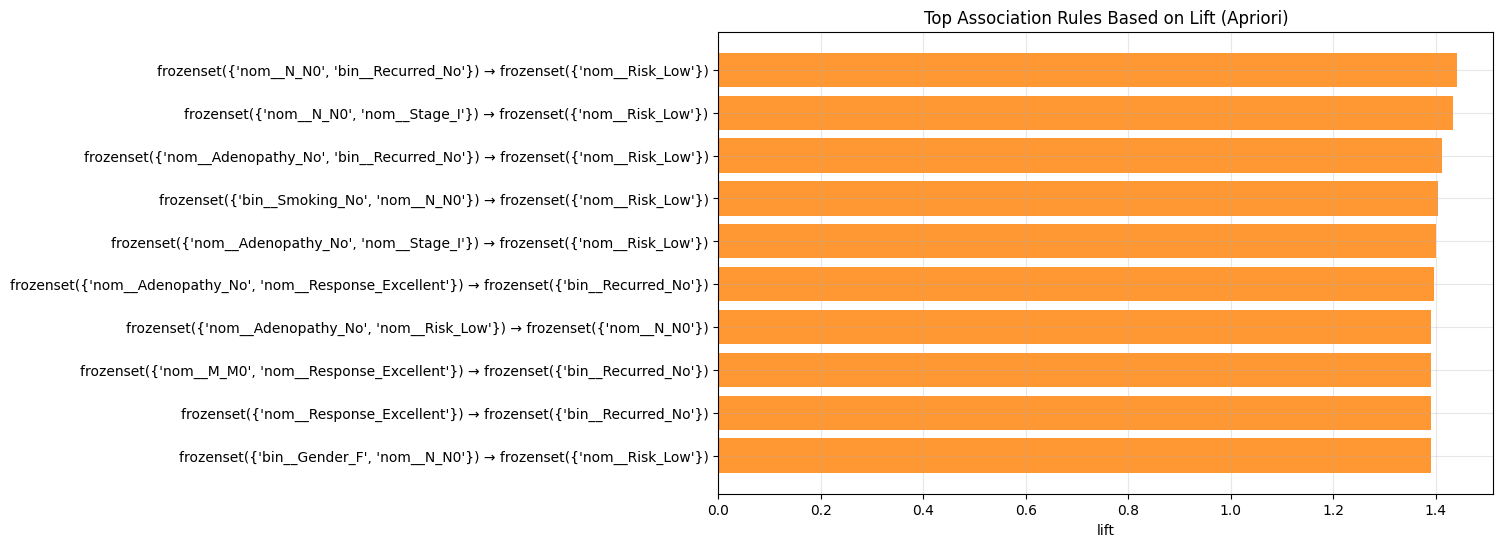

In [43]:
plot_top_rules(
    apriori_rules_filtered,
    metric="lift",
    n=10,
    title="Top Association Rules Based on Lift (Apriori)"
)

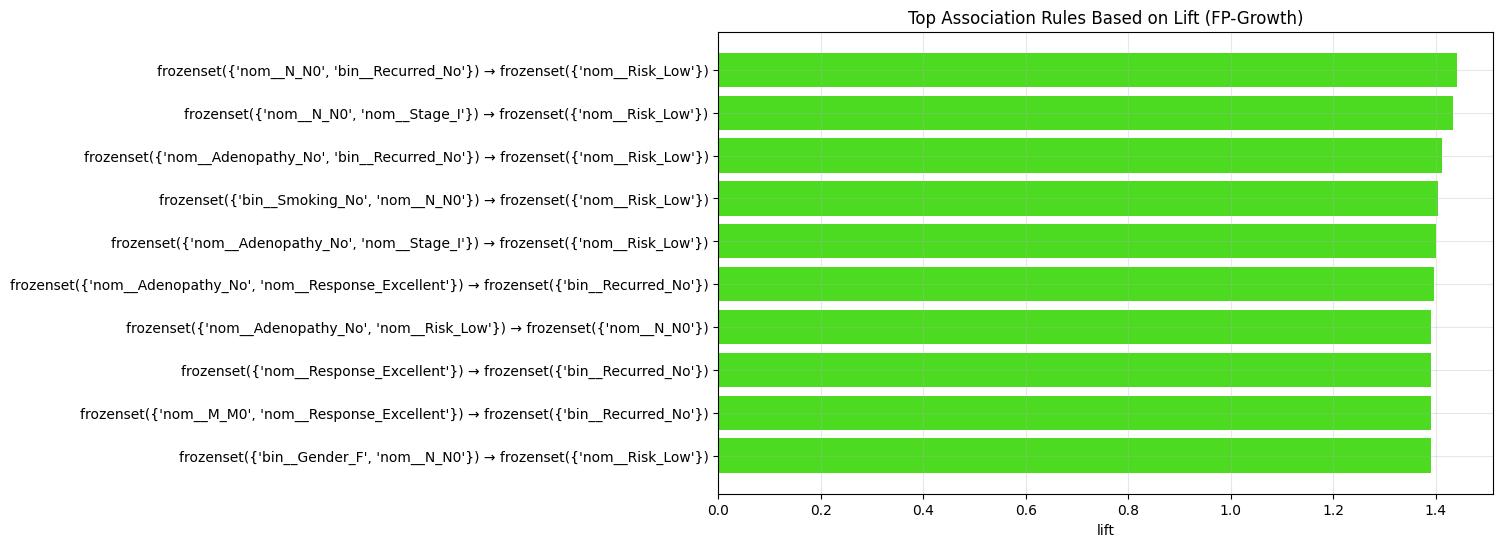

In [45]:
plot_top_rules(
    fpgrowth_rules_filtered,
    metric="lift",
    n=10,
    title="Top Association Rules Based on Lift (FP-Growth)",
    color="#4cdb20"
)

#### 3. Support vs Confidence Scatter Plot

In [89]:
def plot_support_confidence_side_by_side(
    rules_apriori,
    rules_fpgrowth,
    title_apriori="Association Rules (Apriori): Support vs Confidence",
    title_fpgrowth="Association Rules (FP-Growth): Support vs Confidence",
    figsize=(16, 6)
):
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)

    # ---- Left plot: Apriori ----
    scatter1 = ax1.scatter(
        rules_apriori["support"],
        rules_apriori["confidence"],
        s=rules_apriori["lift"] * 50,
        c=rules_apriori["lift"],
        cmap="viridis",
        alpha=0.7
    )
    fig.colorbar(scatter1, ax=ax1, label="Lift")
    ax1.set_xlabel("Support")
    ax1.set_ylabel("Confidence")
    ax1.set_title(title_apriori)
    ax1.grid(alpha=0.3)

    # ---- Right plot: FP-Growth ----
    scatter2 = ax2.scatter(
        rules_fpgrowth["support"],
        rules_fpgrowth["confidence"],
        s=rules_fpgrowth["lift"] * 50,
        c=rules_fpgrowth["lift"],
        cmap="viridis",
        alpha=0.7
    )
    fig.colorbar(scatter2, ax=ax2, label="Lift")
    ax2.set_xlabel("Support")
    ax2.set_ylabel("Confidence")
    ax2.set_title(title_fpgrowth)
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

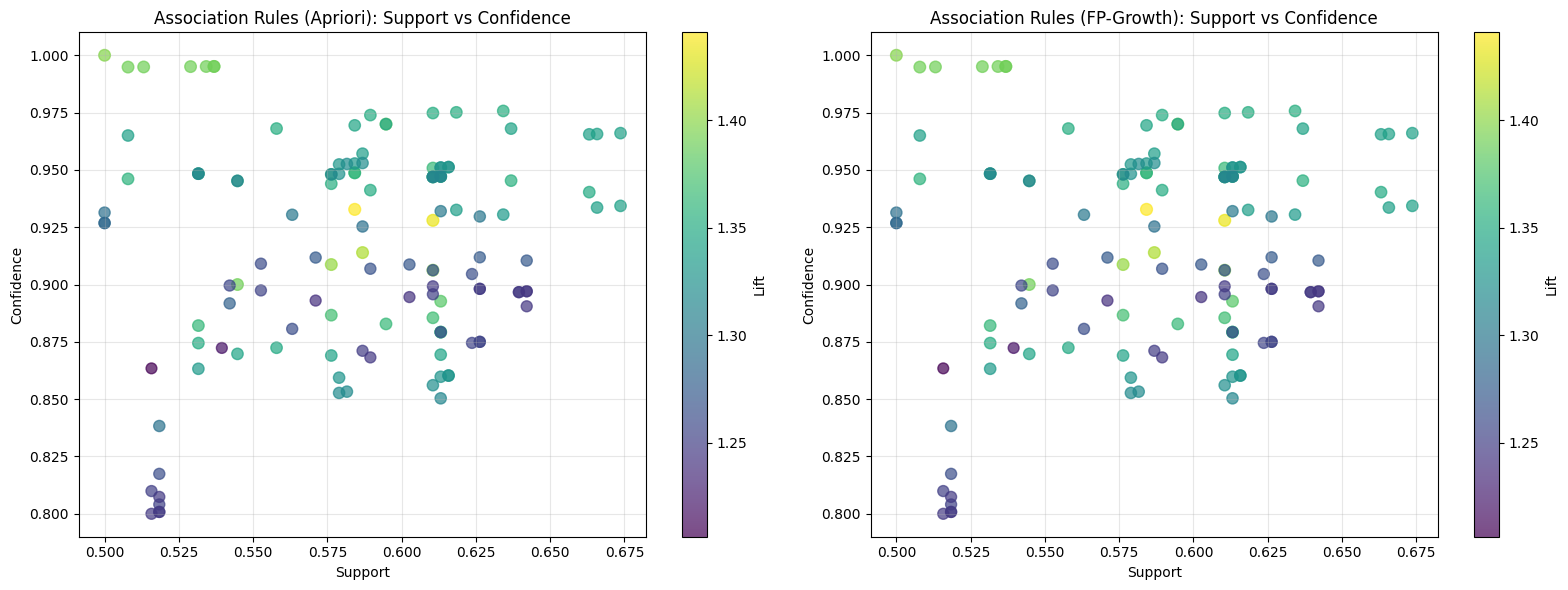

In [90]:
plot_support_confidence_side_by_side(
    apriori_rules_filtered,
    fpgrowth_rules_filtered
)

**The ideal rules are:**

- high support
- high confidence
- high lift

Usually located in the upper-right region.

#### 4. Metric Distribution Analysis

In [73]:
def plot_metric_distribution(
    rules,
    color="#3932ff"
):

    metrics = [
        "support",
        "confidence",
        "lift",
        "leverage",
        "conviction"
    ]

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()

    for ax, metric in zip(axes, metrics):
        sns.histplot(
            rules[metric],
            bins=15,
            kde=True,
            ax=ax,
            color=color
        )
        ax.set_title(metric)

    fig.delaxes(axes[5])  # Remove the empty subplot
    plt.tight_layout()
    plt.show()

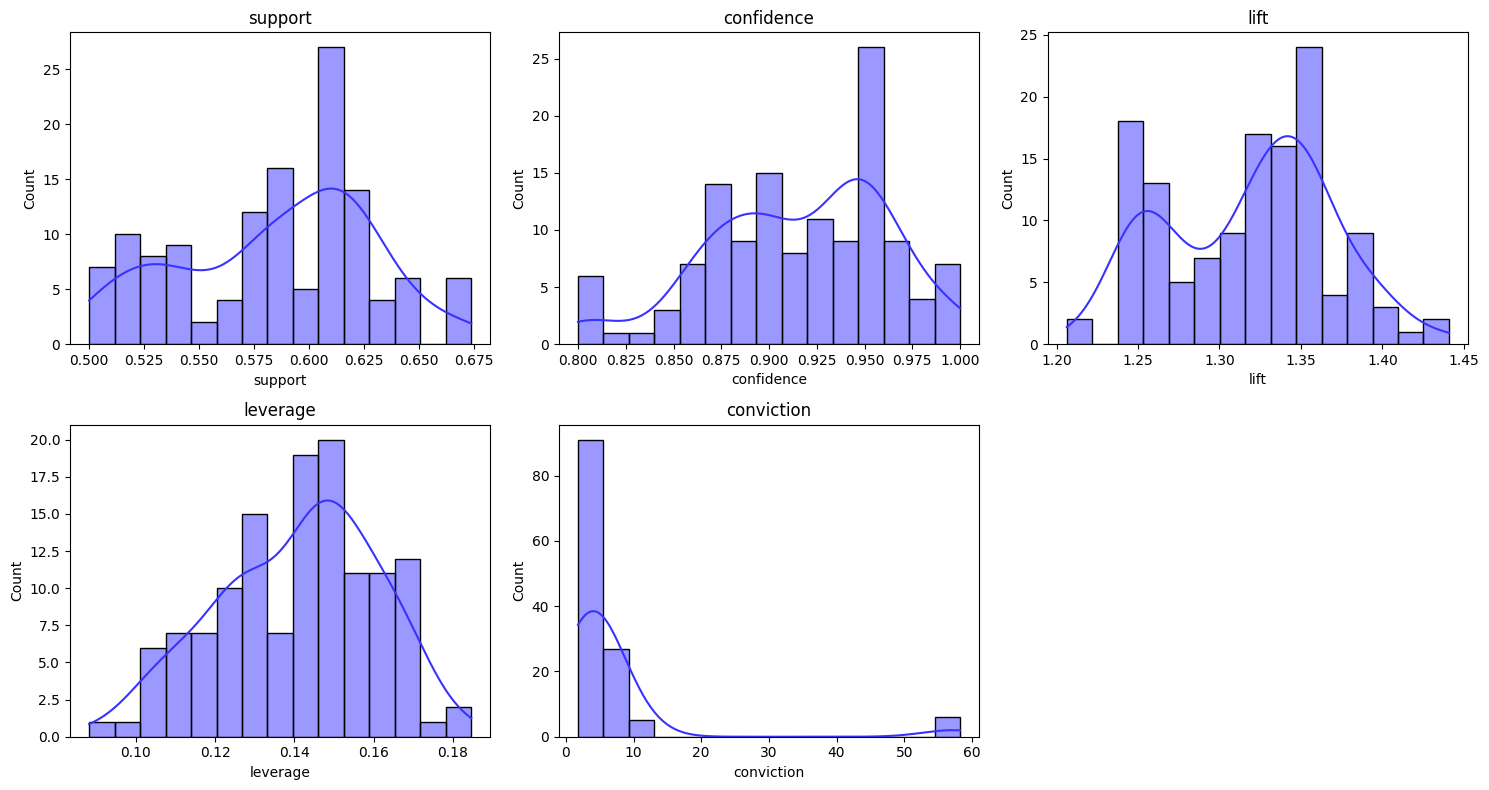

In [74]:
plot_metric_distribution(apriori_rules_filtered)

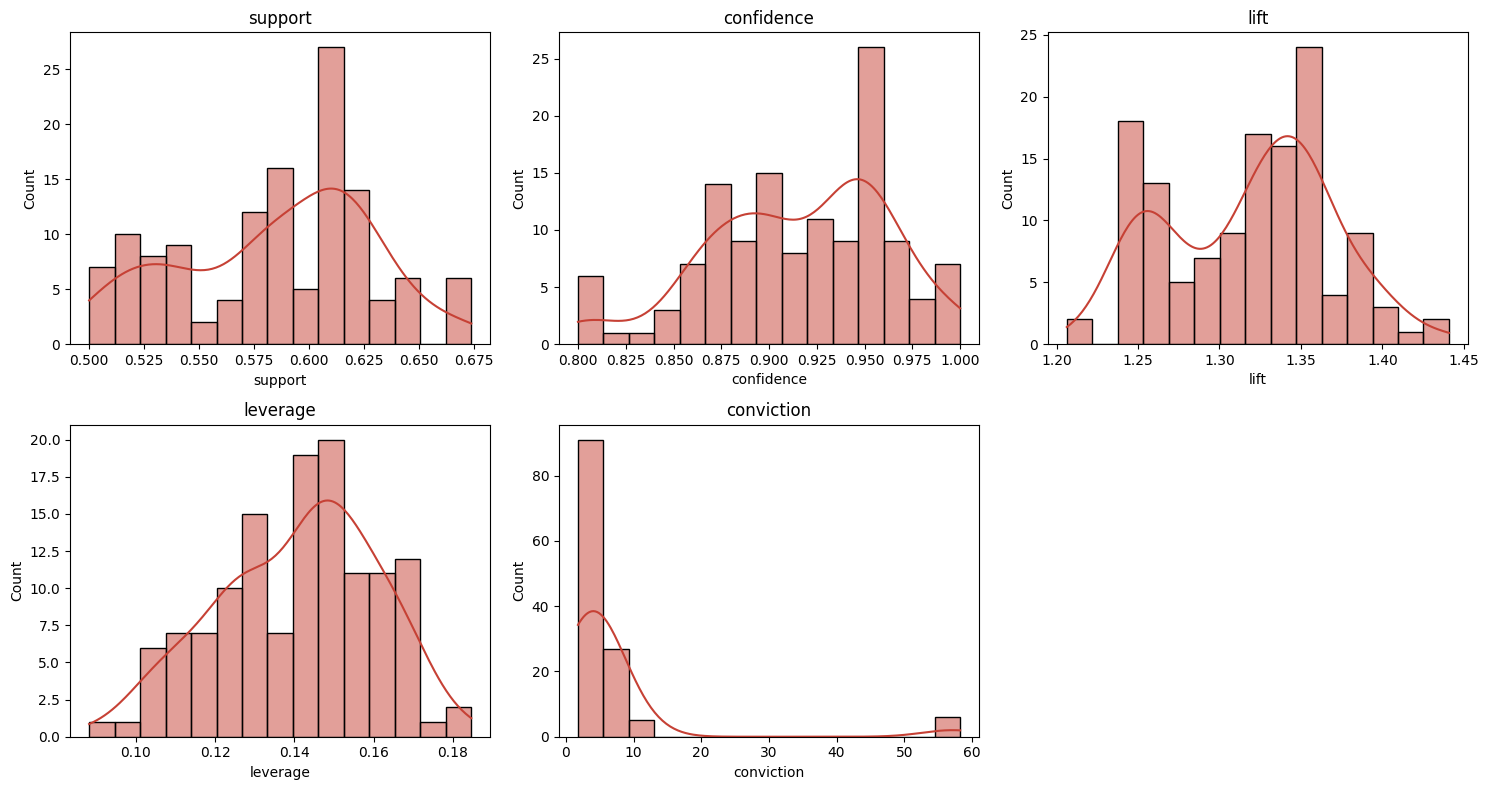

In [75]:
plot_metric_distribution(fpgrowth_rules_filtered, color="#c64135")

#### 5. Antecedent Frequency Analysis

In [ ]:
def plot_feature_frequency(
    rules,
    algo,
    color="#ff2298"
):

    items=[]

    for antecedent in rules["antecedents"]:
        items.extend(list(antecedent))

    counts = (
        pd.Series(items)
        .value_counts()
        .head(15)
    )

    plt.figure(figsize=(13,6))

    sns.barplot(
        x=counts.values,
        y=counts.index,
        color=color
    )

    plt.xlabel("Frequency in Rules")
    plt.ylabel("Clinical Feature")
    plt.title(f"Most Frequent Features in Association Rules - {algo}")
    plt.grid(alpha=0.3)
    plt.show()


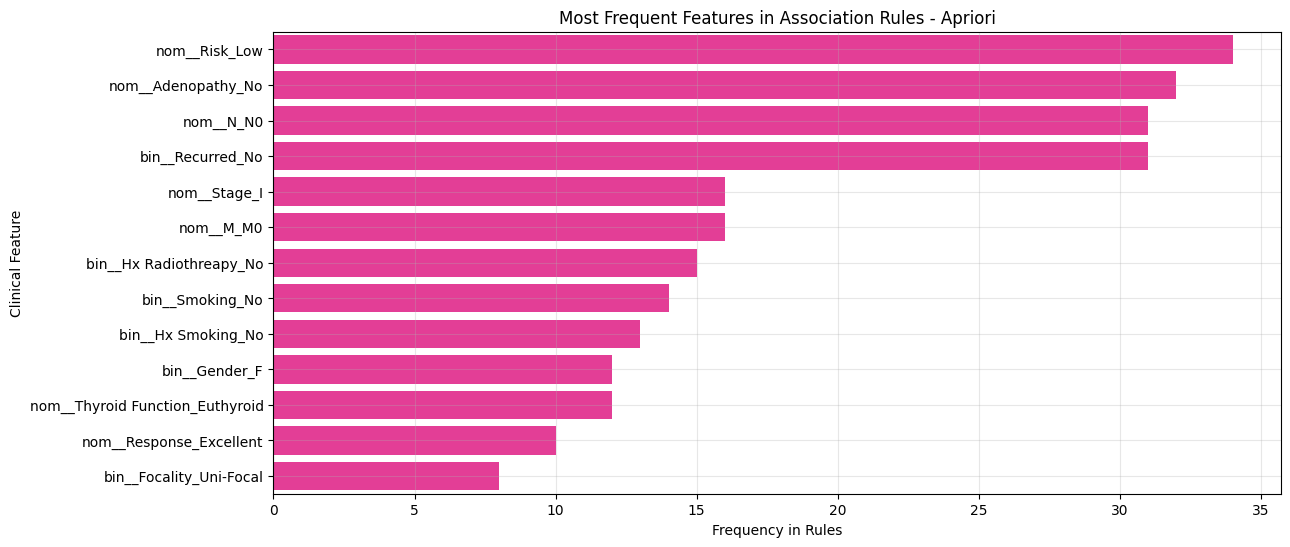

In [86]:
plot_feature_frequency(apriori_rules_filtered, "Apriori")

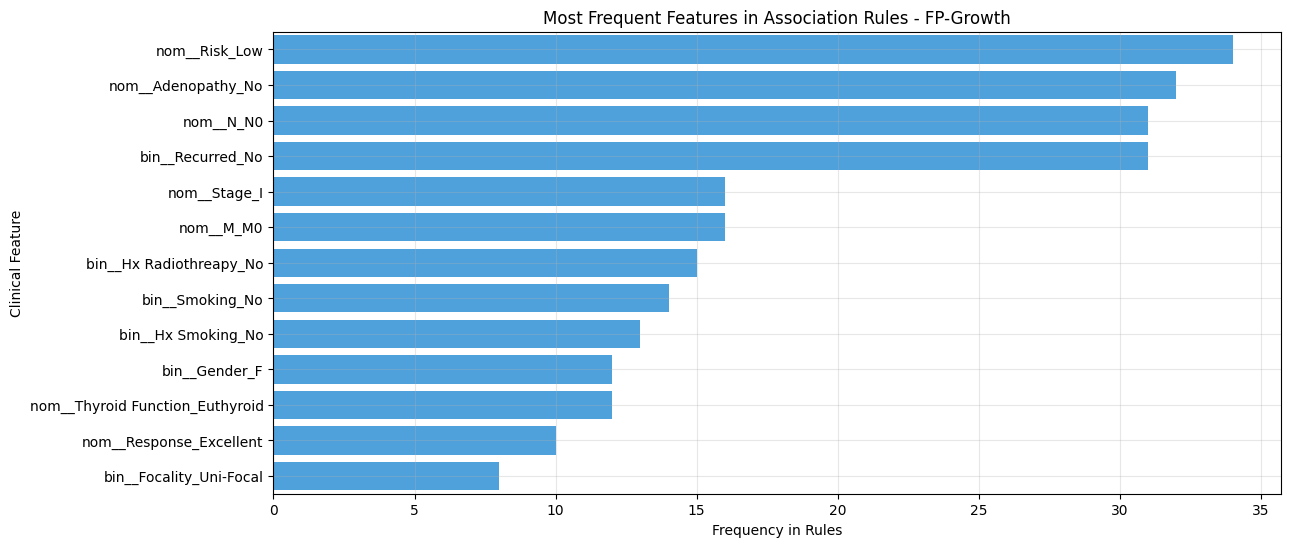

In [87]:
plot_feature_frequency(fpgrowth_rules_filtered, "FP-Growth", "#37a5f4")

#### 6. Association Rule Heatmap

In [122]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_rule_metrics_heatmap(
    rules,
    n_rules=30,
    cmap="YlOrRd"
):
    metrics = [
        "support", "confidence", "lift", "leverage",
        "conviction", "jaccard", "kulczynski", "zhangs_metric"
    ]

    # ---- Select top rules ----
    heatmap_df = (
        rules.sort_values("lift", ascending=False)
        .head(n_rules)[metrics]
    )

    # ---- Keep original values (including inf) for annotations ----
    original_values = heatmap_df.copy()

    # ---- Replace infinities in each column with a value just above the max finite ----
    # This preserves the colour scaling without distortion.
    scaled_data = heatmap_df.copy()
    for col in scaled_data.columns:
        finite_vals = scaled_data[col][np.isfinite(scaled_data[col])]
        if len(finite_vals) > 0:
            max_finite = finite_vals.max()
            # Replace inf with max_finite * 1.05 (or + 1 if max_finite is tiny)
            # Use a small multiplier to keep it close to the max finite.
            replace_value = max_finite * 1.05 if max_finite > 0 else max_finite + 1.0
            scaled_data[col] = scaled_data[col].replace([np.inf, -np.inf], replace_value)
        else:
            # If all values are inf (unlikely), set them to a default high number
            scaled_data[col] = scaled_data[col].replace([np.inf, -np.inf], 100)

    # ---- Min‑Max scaling per column (now using the replaced values) ----
    scaled_df = (scaled_data - scaled_data.min()) / (scaled_data.max() - scaled_data.min())
    scaled_df = scaled_df.fillna(0)   # fallback if any NaN remains

    # ---- Build annotation matrix from original values ----
    def format_cell(x):
        if np.isinf(x):
            return "∞"
        else:
            return f"{x:.2f}"

    annot_array = np.vectorize(format_cell)(original_values.values)

    # ---- Plot ----
    plt.figure(figsize=(12, 10))
    sns.heatmap(
        data=scaled_df,
        annot=annot_array,
        fmt="",
        cmap=cmap,
        linewidths=0.5,
        vmin=0,
        vmax=1,
        cbar_kws={"label": "Normalised value (0–1)"}
    )
    plt.title(
        f"Association Rule Metrics Heatmap - Top {n_rules} Rules",
        fontsize=14
    )
    plt.xlabel("Metrics")
    plt.ylabel("Rules ranked by Lift")
    plt.tight_layout()
    plt.show()

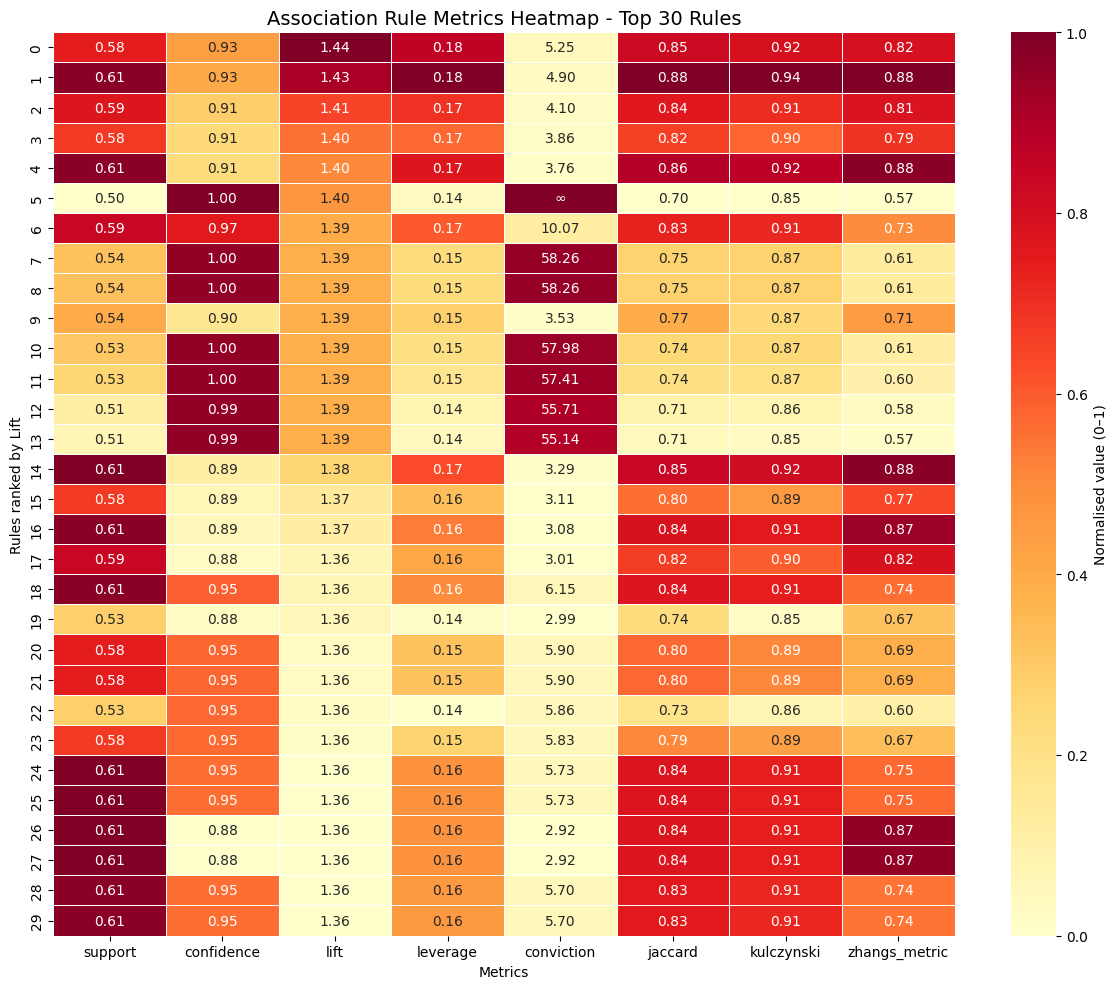

In [123]:
plot_rule_metrics_heatmap(
    apriori_rules_filtered,
)

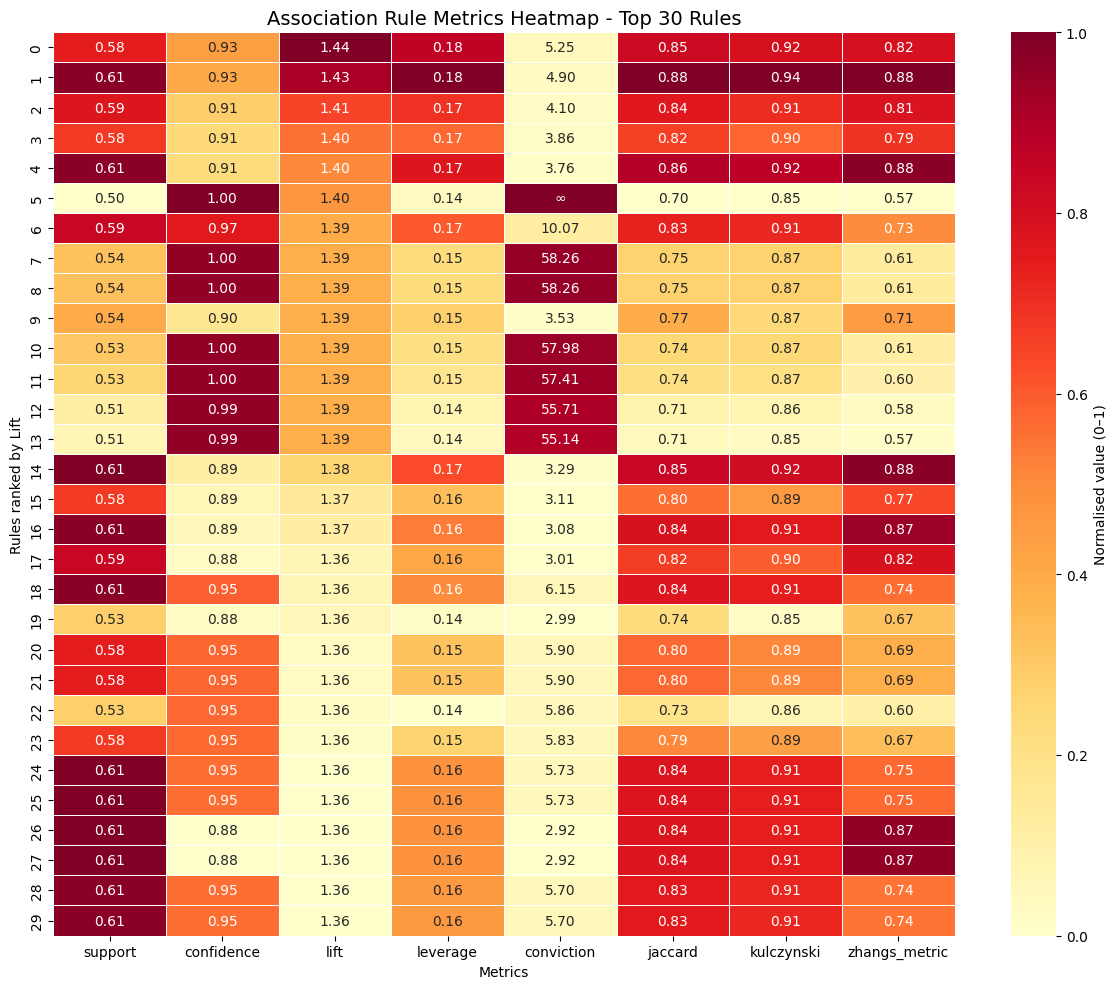

In [124]:
plot_rule_metrics_heatmap(
    fpgrowth_rules_filtered,
)

### 6) Association Rules Related to Disease Recurrence

In [145]:
# ==========================================================
# Rules predicting Recurred = Yes
# ==========================================================

# Since the algorithms are indetical we only use one of them in this case
def find_recurred_yes(X):
    recurred_rules = X[
        X["consequents"].apply(
            lambda x: x == frozenset({"bin__Recurred_Yes"})
        )
    ].copy()

    print(f"Number of rules: {len(recurred_rules)}")
    return recurred_rules

_ = find_recurred_yes(apriori_rules)

Number of rules: 0


In [134]:
transactions["bin__Recurred_Yes"].mean()

np.float64(0.28421052631578947)

> Because we set min support to 0.5 we lost the recurred_yes=0.28 so to experiment and see recurred_yes rules we use a less min soppurt only for this purpose. 

In [136]:
apriori_itemsets_rec, fp_itemsets_rec = apply_itemsets_generation(transactions, min_support=0.2)

In [141]:
apriori_rules_rec = generate_rules(
    apriori_itemsets_rec,
    metric="confidence",
    threshold=0.70
)

In [142]:
len(apriori_rules_rec)

3279932

In [146]:
ap_rec_yes = find_recurred_yes(apriori_rules_rec)

Number of rules: 6


In [147]:
ap_rec_yes.sort_values(
    by="lift",
    ascending=False
)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
2392416,frozenset({nom__Response_Structural Incomplete...,frozenset({bin__Recurred_Yes}),0.218421,0.284211,0.215789,0.987952,3.476127,1.0,0.153712,59.410526,0.911390,0.752294,0.983168,0.873606
2768367,frozenset({nom__Response_Structural Incomplete...,frozenset({bin__Recurred_Yes}),0.210526,0.284211,0.207895,0.987500,3.474537,1.0,0.148061,57.263158,0.902110,0.724771,0.982537,0.859491
3227790,frozenset({nom__Response_Structural Incomplete...,frozenset({bin__Recurred_Yes}),0.202632,0.284211,0.200000,0.987013,3.472823,1.0,0.142410,55.115789,0.893000,0.697248,0.981856,0.845358
1919124,frozenset({nom__Response_Structural Incomplete}),frozenset({bin__Recurred_Yes}),0.239474,0.284211,0.234211,0.978022,3.441188,1.0,0.166150,32.568421,0.932779,0.809091,0.969295,0.901048
2276075,frozenset({nom__Response_Structural Incomplete...,frozenset({bin__Recurred_Yes}),0.226316,0.284211,0.221053,0.976744,3.436693,1.0,0.156731,30.778947,0.916424,0.763636,0.967510,0.877261
2941380,frozenset({nom__Response_Structural Incomplete...,frozenset({bin__Recurred_Yes}),0.210526,0.284211,0.205263,0.975000,3.430556,1.0,0.145429,28.631579,0.897436,0.709091,0.965074,0.848611


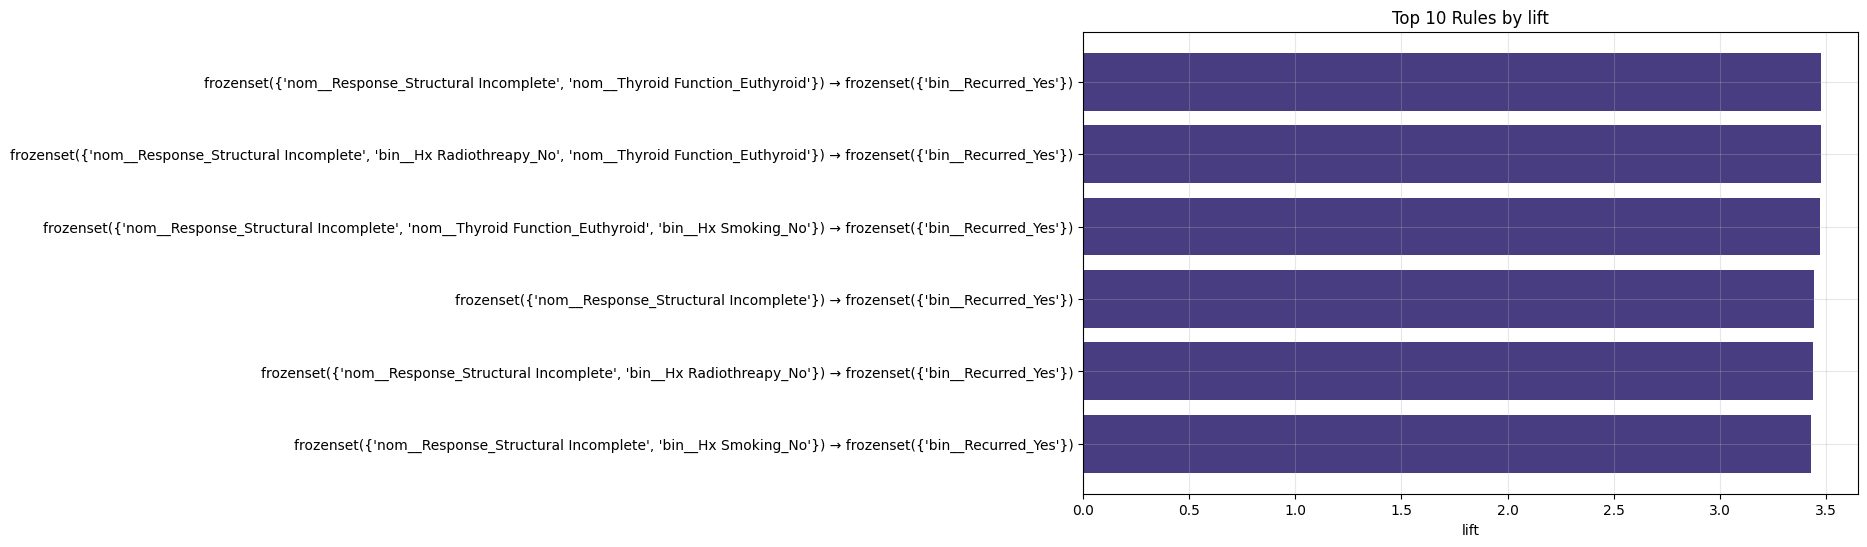

In [150]:
plot_top_rules(ap_rec_yes, color="#483d81")

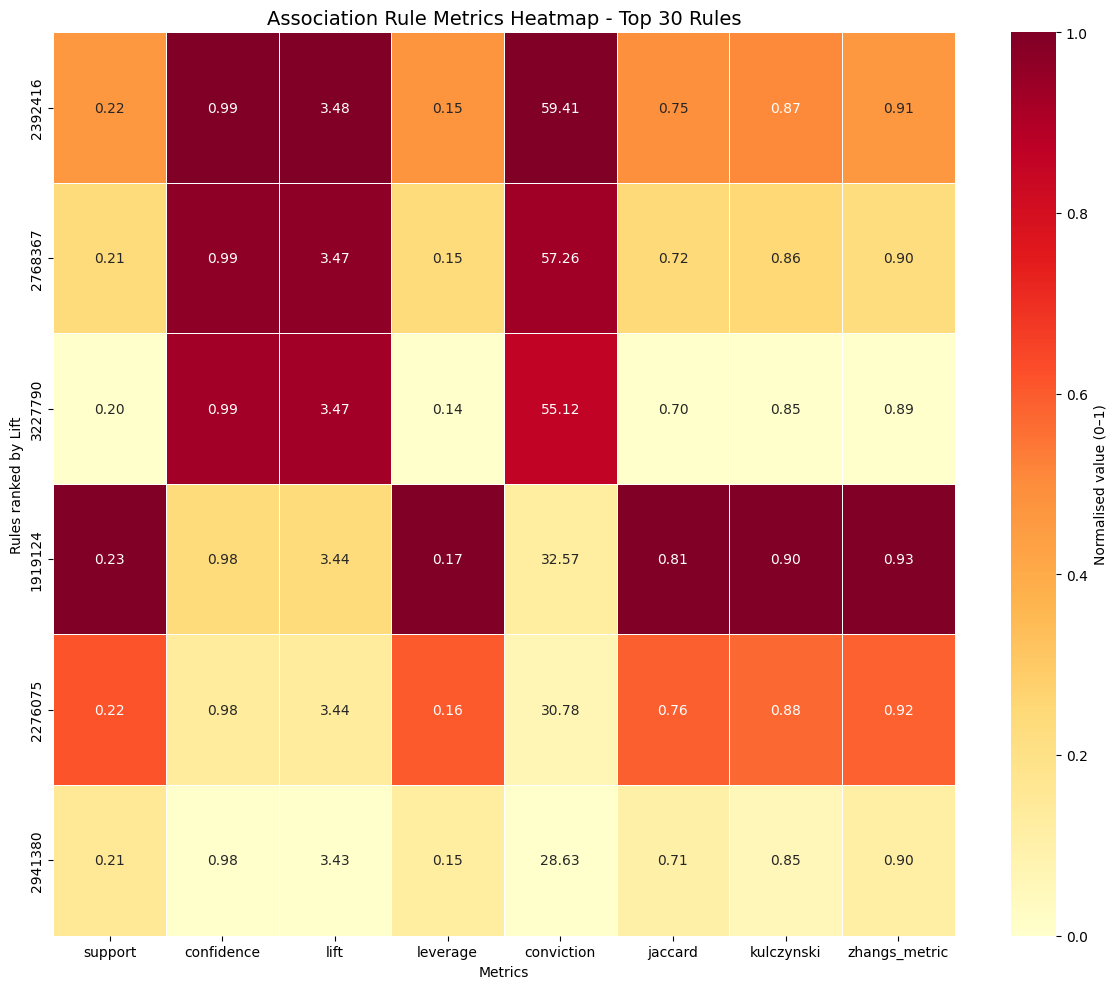

In [148]:
plot_rule_metrics_heatmap(ap_rec_yes)

#### Additional Analysis: Rules Associated with Disease Recurrence

To further investigate clinically meaningful patterns, the minimum support threshold was temporarily reduced from 0.40 to 0.20, allowing less frequent itemsets involving recurrence to be discovered. This produced over 3.2 million association rules, from which only six satisfied the condition that the consequent consisted solely of Recurred = Yes.

Interestingly, all six rules shared the clinical feature Response = Structural Incomplete within their antecedents and exhibited extremely high confidence (97.5–98.8%) and lift values around 3.4–3.5. This suggests that structural incomplete response is the dominant characteristic associated with recurrence in this dataset, while additional clinicopathologic variables provide only marginal increases in predictive strength.

### Association Rule Metrics Summary
| Metric                 |  Range | Interpretation                                                                          | Better Value           |
| ---------------------- | :----: | --------------------------------------------------------------------------------------- | ---------------------- |
| **Support**            |   0–1  | Frequency of the complete rule in the dataset.                                          | Higher                 |
| **Antecedent Support** |   0–1  | Frequency of the left-hand side (antecedent).                                           | Context-dependent      |
| **Consequent Support** |   0–1  | Frequency of the right-hand side (consequent).                                          | Context-dependent      |
| **Confidence**         |   0–1  | Probability of the consequent given the antecedent.                                     | Higher                 |
| **Lift**               |   0–∞  | Strength of association relative to random chance.                                      | > 1 (higher is better) |
| **Leverage**           | -1 – 1 | Difference between observed and expected co-occurrence.                                 | Larger positive        |
| **Conviction**         |   0–∞  | Measures how strongly the antecedent implies the consequent.                            | Higher                 |
| **Representativity**   |   0–1  | Indicates how representative the rule is of the dataset.                                | Higher                 |
| **Jaccard**            |   0–1  | Degree of overlap between antecedent and consequent.                                    | Higher                 |
| **Certainty Factor**   | -1 – 1 | Improvement in predictive certainty over the baseline probability.                      | Higher                 |
| **Kulczynski**         |   0–1  | Balanced measure of association considering both directions.                            | Higher                 |
| **Zhang's Metric**     | -1 – 1 | Measures the strength and direction of association while correcting for item imbalance. | Closer to +1           |


### Mathematical Formulas

**Support**
$$ \text{Support}(A \rightarrow B) = P(A \cap B) $$

**Antecedent Support**
$$ \text{Antecedent Support} = P(A) $$

**Consequent Support**
$$ \text{Consequent Support} = P(B) $$

**Confidence**
$$ \text{Confidence}(A \rightarrow B) = \frac{P(A \cap B)}{P(A)} $$

**Lift**
$$ \text{Lift}(A \rightarrow B) = \frac{\text{Confidence}(A \rightarrow B)}{P(B)} = \frac{P(A \cap B)}{P(A)P(B)} $$

**Leverage**
$$ \text{Leverage} = P(A \cap B) - P(A)P(B) $$

**Conviction**
$$ \text{Conviction} = \frac{1 - P(B)}{1 - \text{Confidence}(A \rightarrow B)} $$

**Jaccard**
$$ \text{Jaccard} = \frac{P(A \cap B)}{P(A) + P(B) - P(A \cap B)} $$

**Certainty Factor**
$$ \text{CF} = \frac{\text{Confidence}(A \rightarrow B) - P(B)}{1 - P(B)} \quad (\text{Confidence} \geq P(B)) $$

For negative associations, the denominator changes accordingly, but the above expression is the form most commonly encountered in association rule mining.

**Kulczynski**
$$ \text{Kulczynski} = \frac{1}{2} \left( P(B \mid A) + P(A \mid B) \right) $$

**Zhang's Metric**
$$ \text{Zhang} = \frac{P(A \cap B) - P(A)P(B)}{\max\left( P(A \cap B)(1 - P(A)),\ P(A)(P(B) - P(A \cap B)) \right)} $$

## Results

Association Rule Mining was applied to the preprocessed transaction dataset using both the Apriori and FP-Growth algorithms. After filtering the generated rules based on minimum support, confidence, and antecedent/consequent sizes, both algorithms produced identical association rules, confirming that they discover the same underlying frequent patterns while differing only in their computational strategy. The strongest rules were primarily characterized by high confidence (approximately 0.85–1.00) and lift values greater than one, indicating positive associations beyond random chance. Frequent clinical characteristics appearing within these rules included low-risk classification, absence of lymph node metastasis (N0), absence of adenopathy, early disease stage, favorable treatment response, and non-recurrent disease.

The visualizations further demonstrated that most discovered rules exhibit relatively high support and confidence while maintaining moderate lift values, suggesting stable and meaningful relationships among multiple clinicopathologic variables. Feature frequency analysis revealed that several variables consistently appeared as central nodes across numerous association rules, highlighting their importance within the overall clinical structure of the dataset.

## Conclusion

Association Rule Mining successfully identified interpretable relationships among clinicopathologic characteristics without requiring any predictive model or target variable during training. Unlike clustering and anomaly detection, which primarily group patients or identify unusual observations, association rule mining provides explicit and human-readable relationships between clinical variables. The discovered rules revealed several clinically intuitive associations involving disease stage, lymph node status, treatment response, recurrence status, and risk classification.

Overall, this notebook complements the previous unsupervised learning analyses by providing an additional perspective on hidden patterns within the thyroid cancer dataset. Together with clustering, dimensionality reduction, and anomaly detection, association rule mining contributes to a comprehensive exploratory framework for understanding complex biomedical datasets.